<a href="https://colab.research.google.com/github/Profilo-Maps/Parkximity/blob/main/KMeans_in_PCA_space.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import requests
import geopandas as gpd
import pandas as pd
import numpy as np
import glob

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [5]:
# Define Census API key
api_key = "3f206cc5c30dbea45da41bb5ded4daf499f4371a"

# Step 1: Get LA City boundary
la_city_url = "https://opendata.arcgis.com/datasets/09f503229d37414a8e67a7b6ceb9ec43_7.geojson"
la_city = gpd.read_file(la_city_url)
la_city = la_city.to_crs(epsg=4326)

# Step 2: Load census tracts
tracts = gpd.read_file("GeoJSON:/content/la_tracts.geojson")
tracts['GEOID'] = '06037' + tracts['CT20'].astype(str).str.replace('.', '').str.zfill(6)

# Step 3: Filter tracts in LA City
tracts_in_la = gpd.sjoin(tracts, la_city, how='inner', predicate='intersects')
la_tract_geoids = tracts_in_la['GEOID'].unique()

# Step 4: Fetch ACS data
variables = [
    "B19013_001E",  # Median Household Income
    "B08201_001E",  # Total households
    "B08201_002E",  # Households with no vehicle
    "B08014_001E",  # Aggregate vehicles
    "B03003_003E",  # Hispanic or Latino
    "B03002_003E",  # Non-Hispanic White
    "B03002_004E",  # Non-Hispanic Black
    "B03002_006E",  # Non-Hispanic Asian
    "B01003_001E",  # Total Population
    "B25001_001E",  # Total Housing Units
    "B08301_001E",  # Total commuters
    "B08301_002E",  # Drove alone
    "B08301_003E"   # Carpooled
]

base_url = "https://api.census.gov/data/2023/acs/acs5"
params = {
    "get": ",".join(["NAME"] + variables),
    "for": "tract:*",
    "in": "state:06 county:037",
    "key": api_key
}

response = requests.get(base_url, params=params)
data = response.json()
df = pd.DataFrame(data[1:], columns=data[0])

# Convert to numeric
for col in variables:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Create GEOID and filter to LA City
df['GEOID'] = df['state'] + df['county'] + df['tract']
df_la_city = df[df['GEOID'].isin(la_tract_geoids)].copy()

# Rename columns
df_la_city = df_la_city.rename(columns={
    'B19013_001E': 'median_household_income',
    'B08201_001E': 'total_households',
    'B08201_002E': 'households_no_vehicle',
    'B08014_001E': 'aggregate_vehicles',
    'B03003_003E': 'hispanic_latino',
    'B03002_003E': 'nh_white',
    'B03002_004E': 'nh_black',
    'B03002_006E': 'nh_asian',
    'B01003_001E': 'total_population',
    'B25001_001E': 'total_housing_units',
    'NAME': 'tract_name'
})

# Calculate area
tracts_in_la_proj = tracts_in_la.to_crs(epsg=3857)
tracts_in_la_proj['tract_area_sq_miles'] = tracts_in_la_proj.geometry.area / 2589988.11
tract_area_df = tracts_in_la_proj[['GEOID', 'tract_area_sq_miles']].drop_duplicates(subset=['GEOID'])
df_la_city = df_la_city.merge(tract_area_df, on='GEOID', how='left')

# Calculate all metrics
df_la_city['mean_vehicles_per_household'] = (df_la_city['aggregate_vehicles'] / df_la_city['total_households']).round(2)
df_la_city['hispanic_percent'] = (df_la_city['hispanic_latino'] / df_la_city['total_population'] * 100).round(2)
df_la_city['non_hispanic_white_percent'] = (df_la_city['nh_white'] / df_la_city['total_population'] * 100).round(2)
df_la_city['non_hispanic_black_percent'] = (df_la_city['nh_black'] / df_la_city['total_population'] * 100).round(2)
df_la_city['non_hispanic_asian_percent'] = (df_la_city['nh_asian'] / df_la_city['total_population'] * 100).round(2)
df_la_city['vehicles_per_person'] = (df_la_city['aggregate_vehicles'] / df_la_city['total_population']).round(2)
df_la_city['housing_units_per_sq_mile'] = (df_la_city['total_housing_units'] / df_la_city['tract_area_sq_miles']).round(2)
df_la_city['population_density_per_sq_mile'] = (df_la_city['total_population'] / df_la_city['tract_area_sq_miles']).round(2)

# Filter out tracts with fewer than 10 households
df_la_city = df_la_city[df_la_city['total_households'] >= 10].copy()

# Filter out tracts with negative median household income
df_la_city = df_la_city[df_la_city['median_household_income'] >= 0].copy()

# Filter out tracts where total_population is 0 or NaN
df_la_city = df_la_city[df_la_city['total_population'] > 0].copy()

# Filter out tracts where tract_area_sq_miles is 0 or NaN
df_la_city = df_la_city[df_la_city['tract_area_sq_miles'] > 0].copy()

# Clip percentage columns to 0-100 range
percentage_cols = [
    'hispanic_percent',
    'non_hispanic_white_percent',
    'non_hispanic_black_percent',
    'non_hispanic_asian_percent',
]
for col in percentage_cols:
    df_la_city[col] = df_la_city[col].clip(lower=0, upper=100)

# Save CSV
df_la_city.to_csv("la_city_acs_2023_tract_data.csv", index=False)

# Save GeoJSON
df_la_city_geo = tracts_in_la[['GEOID', 'geometry']].merge(
    df_la_city[['GEOID', 'median_household_income', 'mean_vehicles_per_household',
                'total_households', 'hispanic_latino', 'nh_white', 'nh_black', 'nh_asian',
                'total_population', 'total_housing_units', 'tract_area_sq_miles',
                'hispanic_percent', 'non_hispanic_white_percent', 'non_hispanic_black_percent',
                'non_hispanic_asian_percent', 'vehicles_per_person', 'housing_units_per_sq_mile',
                'population_density_per_sq_mile']],
    on='GEOID',
    how='inner'
)
df_la_city_geo.to_file("la_city_acs_2023_tract_data.geojson", driver='GeoJSON')

In [6]:
import geopandas as gpd
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load data
parcels = gpd.read_file("/content/la_parcels_parkximity.geojson")
tracts_demo = gpd.read_file("/content/la_city_acs_2023_tract_data.geojson")

# Align CRS
parcels = parcels.to_crs(tracts_demo.crs)

# Spatial join: attach tract demographics to parcels
parcels_pts = parcels.copy()
parcels_pts["geometry"] = parcels_pts.geometry.representative_point()

joined = gpd.sjoin(parcels_pts, tracts_demo, how="inner", predicate="within")

# Restore original parcel geometry
joined = joined.drop(columns=["geometry"]).merge(
    parcels[["geometry"]], left_index=True, right_index=True, how="left"
)
joined = gpd.GeoDataFrame(joined, geometry="geometry", crs=parcels.crs)

# Log-transform distance columns
for c in joined.columns:
    if "dist" in c.lower() and pd.api.types.is_numeric_dtype(joined[c]):
        joined[c] = np.log1p(joined[c].clip(lower=0))

# Select numeric features
exclude = {"geometry", "geoid", "tract", "tractce", "name"}
feature_cols = [c for c in joined.columns
                if c not in exclude and pd.api.types.is_numeric_dtype(joined[c])]

# Clean and prepare feature matrix
X = joined[feature_cols].replace([np.inf, -np.inf], np.nan).dropna()
g = joined.loc[X.index].copy()

# Scale and apply PCA
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=0.75, random_state=42)
X_pca = pca.fit_transform(X_scaled)

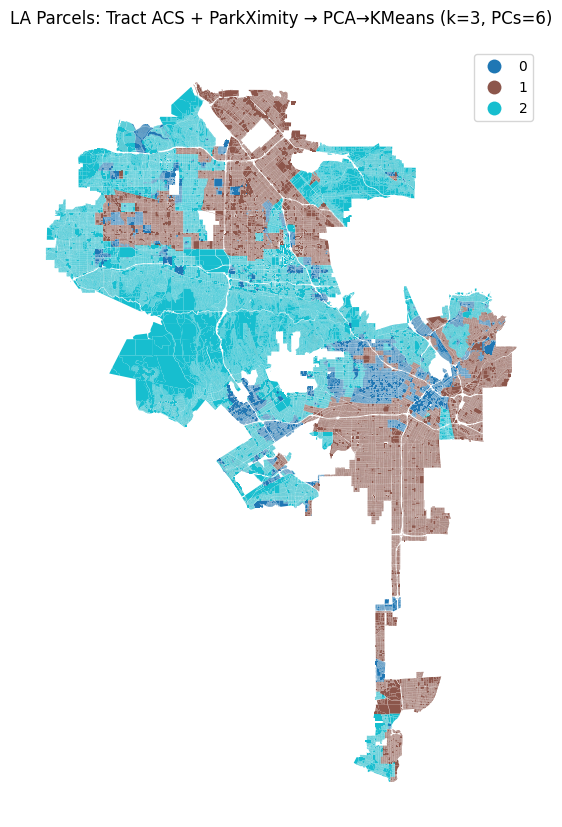

In [12]:
# 6) KMeans on PCA space
k = 3
g["kmeans"] = KMeans(n_clusters=k, n_init="auto", random_state=42).fit_predict(X_pca).astype(int)

# 7) Map clusters
g_3857 = g.to_crs(3857)
ax = g_3857.plot(column="kmeans", categorical=True, legend=True, linewidth=0, figsize=(10,10))
ax.set_axis_off()
ax.set_title(f"LA Parcels: Tract ACS + ParkXimity → PCA→KMeans (k={k}, PCs={X_pca.shape[1]})")
plt.show()

In [13]:

cluster_summary_mean = g.groupby("kmeans")[feature_cols].mean()
cluster_summary_median = g.groupby("kmeans")[feature_cols].median()
cluster_sizes = g["kmeans"].value_counts().sort_index()

print("Cluster sizes:\n", cluster_sizes)
display(cluster_summary_mean)
display(cluster_summary_median)

Cluster sizes:
 kmeans
0    129482
1    325920
2    345989
Name: count, dtype: int64


,park_distance,park_distance_km,index_right,median_household_income,mean_vehicles_per_household,total_households,hispanic_latino,nh_white,nh_black,nh_asian,total_population,total_housing_units,tract_area_sq_miles,hispanic_percent,non_hispanic_white_percent,non_hispanic_black_percent,non_hispanic_asian_percent,vehicles_per_person,housing_units_per_sq_mile,population_density_per_sq_mile
kmeans,,,,,,,,,,,,,,,,,,,,
0,5.824187,0.431186,591.645727,89042.014396,1.237103,1526.325806,943.592368,1121.007422,193.049320,864.696985,3310.023432,1686.415903,0.337708,27.412881,35.763362,5.864814,25.314357,0.568514,8190.877048,14916.738772
1,6.491836,0.600429,527.389154,72943.694164,1.518710,1190.472530,2577.320787,452.142839,481.821478,260.581520,3891.893940,1257.958198,0.522914,66.051664,11.976483,11.990459,6.888609,0.457961,3177.124676,9887.289594
2,6.618116,0.673000,513.671952,137747.073034,1.233918,1614.020989,708.344887,2327.633471,172.291998,466.043452,3937.103474,1763.012578,1.292708,17.688696,60.586234,4.103299,10.966512,0.506493,2328.149602,4900.746004


,park_distance,park_distance_km,index_right,median_household_income,mean_vehicles_per_household,total_households,hispanic_latino,nh_white,nh_black,nh_asian,total_population,total_housing_units,tract_area_sq_miles,hispanic_percent,non_hispanic_white_percent,non_hispanic_black_percent,non_hispanic_asian_percent,vehicles_per_person,housing_units_per_sq_mile,population_density_per_sq_mile
kmeans,,,,,,,,,,,,,,,,,,,,
0,6.240971,0.413669,594.0,89962.0,1.24,1449.0,795.0,1052.0,142.0,742.0,3158.0,1546.0,0.249795,24.91,35.49,4.31,22.83,0.56,6148.59,11638.47
1,6.655383,0.574339,551.0,70127.0,1.52,1146.0,2509.0,316.0,192.0,186.0,3901.0,1207.0,0.407401,66.76,8.83,4.87,4.79,0.46,2974.96,9310.77
2,6.777997,0.629838,385.0,127781.0,1.23,1546.0,586.0,2221.0,94.0,330.0,3832.0,1688.0,0.866658,15.28,61.41,2.55,9.00,0.50,1848.89,4480.74
